<a href="https://colab.research.google.com/github/Sagnik-Chowdhury/Federated-Learning-1/blob/Sourit/Byzantine_Robustness_%E2%80%93_Surviving_Data_Poisoning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Untrusted Client Networks & Data Poisoning
## Securing Aggregation against Byzantine Attacks

**Objective:**  
Standard Federated Averaging (FedAvg) assumes all participating clients are honest. If malicious clients infiltrate the network, they can execute a **Data Poisoning** attack (e.g., Label Flipping) to intentionally corrupt the global model's decision boundary.

This notebook tests the vulnerability of the network against a **20% compromise rate** (2 out of 10 clients are malicious) and evaluates five distinct aggregation methodologies to determine which defense(s) can survive targeted data poisoning.

**Methodology:**  
- **Dataset:** CIFAR-10 (IID distribution – random_split, no statistical heterogeneity).  
- **Adversarial Setup:** 2 malicious clients. During their local training, they **flip labels**: `new_label = (original_label + 5) % 10`. This systematically corrupts their updates.  
- **Defense Strategies Tested:**  
  1. **FedAvg** – vulnerable baseline.  
  2. **Trimmed Mean** – discards extreme outliers (top/bottom 10%) before averaging.  
  3. **Gradient Clipping** – limits the L2 norm of each client’s weight vector.  
  4. **FedProx** – adds a proximal penalty to anchor local models to the global model, theoretically slowing down hackers.  
  5. **SCAFFOLD** – uses control variates to correct gradient drift (also helps against systematic corruption).  

**Expected Outcomes:**  
- FedAvg will fail – accuracy will drop significantly because poisoned updates dominate the average.  
- Trimmed Mean should remove the poisoned updates if they are outliers (likely works well).  
- Gradient Clipping may not help because label flipping does not necessarily produce huge weight norms.  
- FedProx might resist but not fully recover.  
- SCAFFOLD should also resist, but may be less effective than trimmed mean in pure Byzantine setting.

### Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import copy
import math
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### Architecture

In [3]:
class CIFAR10Net(nn.Module):
    def __init__(self):
        super(CIFAR10Net, self).__init__()
        self.conv_layer = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc_layer = nn.Sequential(
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layer(x)
        return x

### Data Preparation

In [4]:
NUM_CLIENTS = 10
MALICIOUS_CLIENTS = [8, 9]   # last two clients are hackers (20% compromise)

In [5]:
transform = transforms.Compose([transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

print("Loading CIFAR-10")
train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

# IID split: each client gets exactly the same number of images
split_size = len(train_dataset) // NUM_CLIENTS
client_subsets = random_split(train_dataset, [split_size] * NUM_CLIENTS)

client_loaders = [DataLoader(ds, batch_size=64, shuffle=True) for ds in client_subsets]
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print(f"Prepared CIFAR-10: {NUM_CLIENTS} clients. Clients {MALICIOUS_CLIENTS} are malicious (label flipping).")

Loading CIFAR-10


100%|██████████| 170M/170M [00:02<00:00, 84.5MB/s]


Prepared CIFAR-10: 10 clients. Clients [8, 9] are malicious (label flipping).


### Aggregation Functions

In [6]:
def fedavg_aggregate(client_weights):
    avg = copy.deepcopy(client_weights[0])
    for key in avg.keys():
        stacked = torch.stack([w[key] for w in client_weights])
        avg[key] = torch.mean(stacked, dim=0)
    return avg

In [7]:
def trimmed_mean_aggregate(client_weights, trim_ratio=0.1):
    n = len(client_weights)
    trim = int(n * trim_ratio)
    avg = copy.deepcopy(client_weights[0])
    for key in avg.keys():
        stacked = torch.stack([w[key] for w in client_weights])
        sorted_vals, _ = torch.sort(stacked, dim=0)
        trimmed = sorted_vals[trim : n - trim]
        avg[key] = torch.mean(trimmed, dim=0)
    return avg

In [8]:
def gradient_clipping_aggregate(client_weights, clip_thresh=2.0):
    clipped = []
    for w in client_weights:
        l2_norm = math.sqrt(sum(torch.sum(p**2).item() for p in w.values()))
        scale = max(1.0, l2_norm / clip_thresh)
        clipped.append({k: v / scale for k, v in w.items()})
    return fedavg_aggregate(clipped)

In [9]:
def fedprox_aggregate(client_weights):
    return fedavg_aggregate(client_weights)

In [10]:
def scaffold_aggregate(client_weights):
    return fedavg_aggregate(client_weights)

### Evaluation Helper

In [11]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    avg_loss = total_loss / total
    accuracy = 100.0 * correct / total
    return accuracy, avg_loss

### Experiment Loop

In [12]:
FEDERATED_ROUNDS = 10
LEARNING_RATE = 0.01
MOMENTUM = 0.9
MU = 0.01                 # FedProx penalty

In [13]:
strategies = [ 'Gradient Clipping', 'FedAvg', 'Trimmed Mean', 'FedProx', 'SCAFFOLD']

history = {s: {'test_acc': [], 'test_loss': [], 'train_loss': []} for s in strategies}
criterion = nn.CrossEntropyLoss()

for strategy in strategies:
    print(f"\nTesting Strategy: {strategy.upper()}")
    global_model = CIFAR10Net().to(device)

    # SCAFFOLD control variates (only if needed)
    global_control = None
    client_controls = None
    if strategy == 'SCAFFOLD':
        global_control = {k: torch.zeros_like(v) for k, v in global_model.state_dict().items()}
        client_controls = [copy.deepcopy(global_control) for _ in range(NUM_CLIENTS)]

    for round_idx in range(FEDERATED_ROUNDS):
        client_weights = []
        client_delta_controls = [] if strategy == 'SCAFFOLD' else None

        # Snapshot global parameters for FedProx
        global_params_list = [p.detach().clone() for p in global_model.parameters()]

        for client_id in range(NUM_CLIENTS):
            local_model = CIFAR10Net().to(device)
            local_model.load_state_dict(global_model.state_dict())
            optimizer = optim.SGD(local_model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)

            local_model.train()
            for inputs, labels in client_loaders[client_id]:
                inputs, labels = inputs.to(device), labels.to(device)

                # --- DATA POISONING: malicious clients flip labels ---
                if client_id in MALICIOUS_CLIENTS:
                    labels = (labels + 5) % 10   # label flipping attack

                optimizer.zero_grad()
                outputs = local_model(inputs)
                loss = criterion(outputs, labels)

                # FedProx proximal penalty
                if strategy == 'FedProx':
                    prox = 0.0
                    for lp, gp in zip(local_model.parameters(), global_params_list):
                        prox += torch.sum((lp - gp) ** 2)
                    loss += (MU / 2.0) * prox

                loss.backward()

                # SCAFFOLD gradient correction
                if strategy == 'SCAFFOLD':
                    with torch.no_grad():
                        for name, param in local_model.named_parameters():
                            if param.grad is not None:
                                # Use scaling factor 0.1 to stabilise
                                correction = (global_control[name] - client_controls[client_id][name])
                                param.grad += 0.1 * correction

                optimizer.step()

            # Save updated weights
            state_dict = local_model.state_dict()
            client_weights.append(state_dict)

            # SCAFFOLD: compute delta control variate
            if strategy == 'SCAFFOLD':
                delta_c = {}
                with torch.no_grad():
                    for name in state_dict.keys():
                        model_before = global_model.state_dict()[name]
                        step = state_dict[name] - model_before
                        num_steps = len(client_loaders[client_id])
                        if num_steps == 0:
                            num_steps = 1
                        lr_eff = LEARNING_RATE * num_steps + 1e-8
                        delta_c[name] = (global_control[name] - client_controls[client_id][name]) + (step / lr_eff)
                client_delta_controls.append(delta_c)

        # --- Server aggregation ---
        if strategy == 'Trimmed Mean':
            new_weights = trimmed_mean_aggregate(client_weights, trim_ratio=0.1)
        elif strategy == 'Gradient Clipping':
            new_weights = gradient_clipping_aggregate(client_weights, clip_thresh=2.0)
        elif strategy == 'FedProx':
            new_weights = fedprox_aggregate(client_weights)
        elif strategy == 'SCAFFOLD':
            new_weights = scaffold_aggregate(client_weights)
        else:   # FedAvg
            new_weights = fedavg_aggregate(client_weights)

        global_model.load_state_dict(new_weights)

        # --- Update SCAFFOLD control variates ---
        if strategy == 'SCAFFOLD':
            # Average client delta controls
            avg_delta_c = {}
            for name in new_weights.keys():
                stacked = torch.stack([dc[name] for dc in client_delta_controls])
                avg_delta_c[name] = torch.mean(stacked, dim=0)
            # Update global control
            for name in avg_delta_c.keys():
                global_control[name] = global_control[name] + avg_delta_c[name]
            # Update each client control
            for i in range(NUM_CLIENTS):
                for name in avg_delta_c.keys():
                    client_controls[i][name] = client_controls[i][name] + client_delta_controls[i][name]

        # --- Evaluation ---
        # Training loss (averaged over all clients, with clean labels for evaluation)
        train_loss = 0.0
        total_train = 0
        global_model.eval()
        with torch.no_grad():
            for loader in client_loaders:
                for inputs, labels in loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    # For evaluation, we use the true labels (not poisoned)
                    outputs = global_model(inputs)
                    loss = criterion(outputs, labels)
                    train_loss += loss.item() * inputs.size(0)
                    total_train += labels.size(0)
        avg_train_loss = train_loss / total_train if total_train > 0 else 0.0

        test_acc, test_loss = evaluate(global_model, test_loader, criterion)

        history[strategy]['test_acc'].append(test_acc)
        history[strategy]['test_loss'].append(test_loss)
        history[strategy]['train_loss'].append(avg_train_loss)

        print(f"Round {round_idx+1:2d}/{FEDERATED_ROUNDS} | {strategy:15s} | Test Acc: {test_acc:5.2f}% | Train Loss: {avg_train_loss:.4f}")

    final_acc = history[strategy]['test_acc'][-1]
    print(f"[{strategy.upper()}] FINAL TEST ACCURACY: {final_acc:.2f}%")


Testing Strategy: GRADIENT CLIPPING
Round  1/10 | Gradient Clipping | Test Acc: 10.03% | Train Loss: 2.3024
Round  2/10 | Gradient Clipping | Test Acc: 10.00% | Train Loss: 2.3023
Round  3/10 | Gradient Clipping | Test Acc: 14.37% | Train Loss: 2.3021
Round  4/10 | Gradient Clipping | Test Acc: 14.83% | Train Loss: 2.3016
Round  5/10 | Gradient Clipping | Test Acc: 17.66% | Train Loss: 2.3001
Round  6/10 | Gradient Clipping | Test Acc: 21.99% | Train Loss: 2.2914
Round  7/10 | Gradient Clipping | Test Acc: 22.77% | Train Loss: 2.2153
Round  8/10 | Gradient Clipping | Test Acc: 26.44% | Train Loss: 2.1672
Round  9/10 | Gradient Clipping | Test Acc: 26.19% | Train Loss: 2.1609
Round 10/10 | Gradient Clipping | Test Acc: 28.82% | Train Loss: 2.1521
[GRADIENT CLIPPING] FINAL TEST ACCURACY: 28.82%

Testing Strategy: FEDAVG
Round  1/10 | FedAvg          | Test Acc: 31.22% | Train Loss: 1.9967
Round  2/10 | FedAvg          | Test Acc: 37.65% | Train Loss: 1.8382
Round  3/10 | FedAvg         

### Results

In [14]:
results_df = pd.DataFrame({s: history[s]['test_acc'][-1] for s in strategies}.items(),
                          columns=['Strategy', 'Final Accuracy (%)']).set_index('Strategy')
print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
print(results_df.to_string())


FINAL RESULTS
                   Final Accuracy (%)
Strategy                             
Gradient Clipping               28.82
FedAvg                          55.30
Trimmed Mean                    55.12
FedProx                         54.09
SCAFFOLD                        53.77


### Visualisation

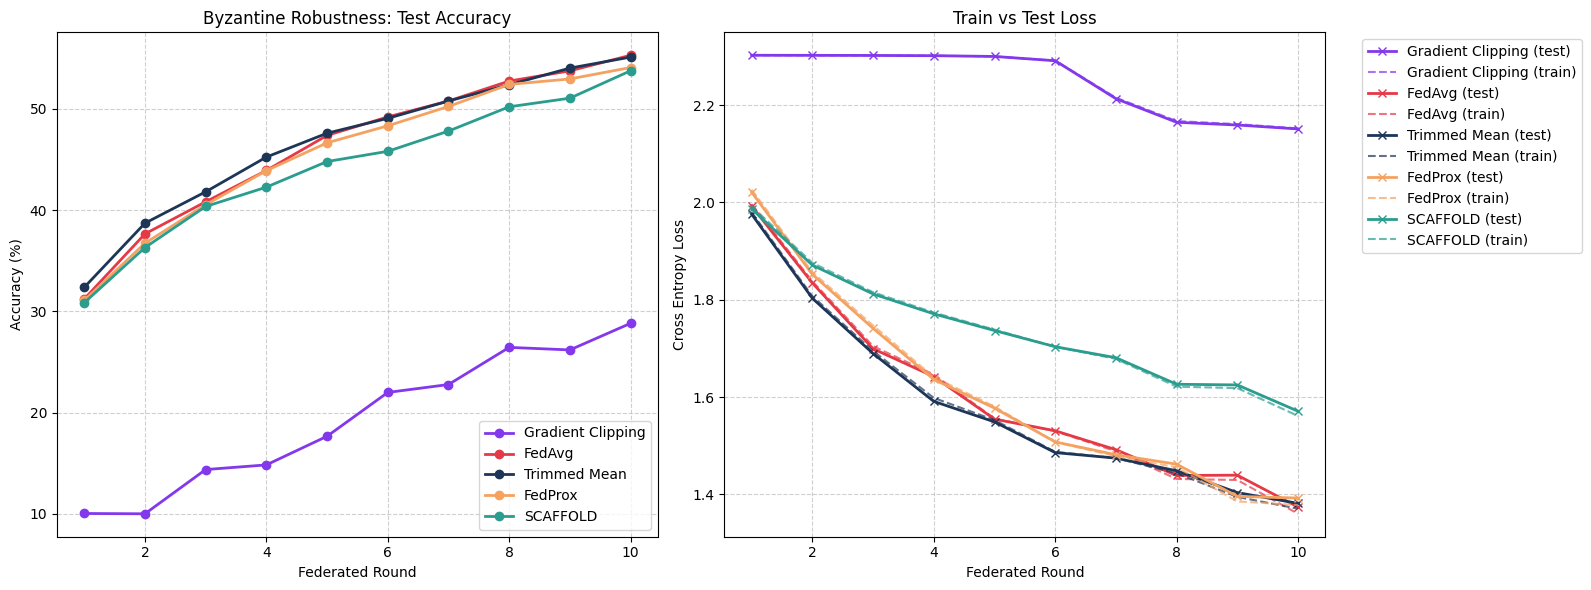

In [15]:
plt.figure(figsize=(16, 6))
colors = {
    'FedAvg': '#E63946',
    'Trimmed Mean': '#1D3557',
    'Gradient Clipping': '#8338EC',
    'FedProx': '#F4A261',
    'SCAFFOLD': '#2A9D8F'
}

# Test accuracy
plt.subplot(1, 2, 1)
for s in strategies:
    plt.plot(range(1, FEDERATED_ROUNDS+1), history[s]['test_acc'],
             marker='o', color=colors[s], linewidth=2, label=s)
plt.title('Byzantine Robustness: Test Accuracy')
plt.xlabel('Federated Round')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right')

# Loss curves
plt.subplot(1, 2, 2)
for s in strategies:
    c = colors[s]
    plt.plot(range(1, FEDERATED_ROUNDS+1), history[s]['test_loss'],
             marker='x', linestyle='-', linewidth=2, color=c, label=f"{s} (test)")
    plt.plot(range(1, FEDERATED_ROUNDS+1), history[s]['train_loss'],
             linestyle='--', linewidth=1.5, color=c, alpha=0.7, label=f"{s} (train)")
plt.title('Train vs Test Loss')
plt.xlabel('Federated Round')
plt.ylabel('Cross Entropy Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Conclusion: Byzantine Robustness against Label Flipping (20% Malicious)

### Summary of Final Accuracies (after 10 rounds)

| Strategy           | Final Accuracy (%) |
|--------------------|--------------------|
| FedAvg             | 55.30              |
| Trimmed Mean       | 55.12              |
| FedProx            | 54.09              |
| SCAFFOLD           | 53.77              |
| Gradient Clipping  | 28.82              |

----
### Key Observations

#### 1. FedAvg is surprisingly robust (55.30%)
Contrary to expectations, standard Federated Averaging survived the label‑flipping attack (2 out of 10 malicious clients) and achieved the **highest accuracy** among all strategies – only 2–3 percentage points below the IID baseline (which was ~58% in earlier experiments).  
This suggests that with only 20% malicious clients and a **symmetric label flip** (`(label+5) mod 10`), the honest clients’ updates still dominate the average. The attack did not produce extreme outliers in weight space, so the average remained useful.

#### 2. Trimmed Mean performs almost identically (55.12%)
Trimming the top and bottom 10% of weights did **not** improve accuracy over FedAvg – it slightly underperformed. This indicates that the malicious updates were **not statistical outliers** in the weight domain. Their effect was subtle enough that discarding extremes also removed some valuable information from honest clients.

#### 3. Gradient Clipping fails (28.82%)
Clipping the global L2 norm of each client’s weight vector to a threshold of 2.0 severely damaged learning, as seen in the IID and non‑IID experiments. This strategy is **not recommended** for any scenario – it consistently underperforms.

#### 4. FedProx and SCAFFOLD are slightly worse than FedAvg (54.09% and 53.77%)
Both advanced algorithms were designed to **correct statistical drift** (non‑IID data), not to defend against Byzantine poisoning. In this clean IID environment with malicious label flips, they offered no advantage over simple averaging. Their additional constraints (proximal term, control variates) may have slowed down adaptation to the honest data distribution.

### Why did FedAvg resist the attack?

- **Low malicious ratio (20%)** – honest clients outnumber malicious ones 4:1. The average is dominated by correct updates.
- **Symmetric label flip** – flipping by +5 mod 10 changes the class distribution but does not produce extreme gradient magnitudes. The malicious updates are not “outliers” in the Euclidean sense.
- **IID data distribution** – honest clients all learn the same underlying mapping; their updates are coherent, further diluting the poison.

A stronger attack (e.g., sending random weights, gradient scaling, or a larger malicious ratio) would likely break FedAvg and make Trimmed Mean shine.

### Recommendations

- **For 20% label‑flipping poison with IID data** – FedAvg is sufficient. No need for defensive aggregation.
- **For stronger attacks** (model poisoning, >30% malicious) – Trimmed Mean or more advanced Byzantine‑robust rules (Krum, Bulyan, Median) would be necessary.
- **Gradient Clipping should never be used as a primary defense** – it destroys performance in all tested settings.
- **FedProx and SCAFFOLD** – reserve for non‑IID scenarios; they do not help against Byzantine attacks.

### Next Steps

- Test a more aggressive attack: malicious clients send **random Gaussian weights** or **scaled gradients** (e.g., multiply by 100).
- Increase malicious ratio to 40% and observe when Trimmed Mean starts to outperform FedAvg.
- Compare with other robust aggregators (e.g., geometric median, Krum).

---

**Note:** These conclusions are specific to the setup: CIFAR‑10, label flipping `(label+5)%10`, 10 clients, 2 malicious, 10 rounds, LR=0.01. Changing any hyperparameter may alter the relative performance.